In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **import packages**

In [ ]:
import os
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import cv2
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image, ImageSequence

DATA_PATH = '/content/drive/MyDrive/CellTrackingDataset/'
OUT_PATH = '/content/drive/MyDrive/CellTrackingDataset/'

from sklearn.utils import validation

In [ ]:
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Cropping2D, Conv2D, Conv2DTranspose, MaxPooling2D, Softmax, AveragePooling2D, UpSampling2D, GlobalAveragePooling2D, Dense, SeparableConv2D
from tensorflow.keras.layers import Input, Add, Multiply, Lambda, Concatenate, Dropout,BatchNormalization,Activation
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# **Load images**

In [ ]:
def load_from_multi_page_tiff(path_to_image):
    image_np_array_list = []
    image_with_multi_page = Image.open(path_to_image)
    for idx, page_image in enumerate(ImageSequence.Iterator(image_with_multi_page)):
        image_np_array_list.append(np.array(page_image))
    return np.stack(image_np_array_list)

def load_from_single_page_tiff(path_to_image):
    return np.array(Image.open(path_to_image))

def get_image_shape(np_array):
    if isinstance(np_array, (np.ndarray, np.generic)):
        print("Loaded data shape: {}".format(np_array.shape))
    else:
        print('Input type error!')

def seek_file_in_folder(folder_path):
    return [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

def parsing_cell_tracking_data(ground_truth_path):
    x_image_array, y_image_array = [], []
    for folder in ground_truth_path:
        image_name_list = seek_file_in_folder(DATA_PATH + folder + '/SEG/')
        seg_image_dict = dict()
        for image_name in image_name_list:
            name = image_name[-7:]
            if '.txt' in name : continue
            seg_image_dict[name] = load_from_single_page_tiff(image_name)
        image_name_list_1 = seek_file_in_folder(DATA_PATH + folder[:-3])
        x_image, y_image = [], []
        for img_name, img_array in seg_image_dict.items():
            matching = [s for s in image_name_list_1 if img_name in s]
            x = load_from_single_page_tiff(matching[0])
            x = cv2.resize(x, dsize = (256, 256))
            y = cv2.resize(img_array, dsize = (256, 256))
            x_image.append(x)
            y_image.append(y)
        x_image_array += x_image
        y_image_array += y_image
    return np.stack(x_image_array), np.stack(y_image_array)

def overlap_tile_processing(img_array, expend_px_width, expend_px_height):
    def flip_horizontally(np_array):
        return cv2.flip(np_array, 1)

    def flip_vertically(np_array):
        return cv2.flip(np_array, 0)

    original_height = img_array.shape[0]
    original_width = img_array.shape[1]

    # Expand width first
    # left:
    left_result = flip_horizontally(img_array[0:0 + original_height, 0:0 + expend_px_width])
    # right:
    right_result = flip_horizontally(
        img_array[0:0 + original_height, original_width - expend_px_width: original_width])

    result_img = cv2.hconcat([left_result, img_array])
    result_img = cv2.hconcat([result_img, right_result])

    result_img_height = result_img.shape[0]
    result_img_width = result_img.shape[1]

    # Expand height
    top_result = flip_vertically(result_img[0:0 + expend_px_height, 0:0 + result_img_width])
    bottom_result = flip_vertically(
        result_img[result_img_height - expend_px_height: result_img_height, 0:0 + result_img_width])

    result_img = cv2.vconcat([top_result, result_img])
    result_img = cv2.vconcat([result_img, bottom_result])

    return result_img

def convert_to_datagen_format(py_list):
    nparray = np.array(py_list)
    return nparray.reshape(nparray.shape + (1,))

def data_generator(x, batch_size=16, epoch=100, seed=2003):
    data_gen_args = dict(rotation_range=90,
                     width_shift_range=0.05,
                     height_shift_range=0.05,
                     shear_range=30,
                     zoom_range=0.05,
                     horizontal_flip=True,
                     vertical_flip=True,
                     fill_mode='reflect')
    datagen = ImageDataGenerator(**data_gen_args)
    datagen_generator = datagen.flow(x, batch_size=batch_size, seed=seed)
    tmp_x, i = list(), 0
    for batch_x in datagen_generator:
        tmp_x += list(batch_x)
        i += 1
        if i >= epoch:
            return np.array(tmp_x)

def split_image2_4patch(imgs):
    ret = list()
    for x in imgs:
        ret.append(x[0:572, 0:572, :].copy())
        ret.append(x[0:572, 124:696, :].copy())
        ret.append(x[124:696, 0:572, :].copy())
        ret.append(x[124:696, 124:696, :].copy())
    return np.array(ret)

**Dataset Loading Functions**##

In [ ]:
def image_histogram_equalization(image, number_bins=256):
    # from http://www.janeriksolem.net/histogram-equalization-with-python-and.html

    # get image histogram
    image_histogram, bins = np.histogram(image.flatten(), number_bins, density=True)
    cdf = image_histogram.cumsum() # cumulative distribution function
    cdf = 255 * cdf / cdf[-1] # normalize

    # use linear interpolation of cdf to find new pixel values
    image_equalized = np.interp(image.flatten(), bins[:-1], cdf)

    return image_equalized.reshape(image.shape), cdf

In [ ]:
def get_DIC_C2DH_HeLa():
    folder_path_list = ['DIC-C2DH-HeLa/01_ST', 'DIC-C2DH-HeLa/02_ST']
    x, y = parsing_cell_tracking_data(folder_path_list)
    get_image_shape(x)
    y[y > 0] = 255
    # x = image_histogram_equalization(x)[0]
    x = np.array(x, dtype = np.float32)/255.0
    y = np.array(y, dtype = np.float32)/255.0
    return x, y

def get_NIH_3T3():
    """
    get NIH 3T3 dataset where had ground truth data only
    :return: x_np_array, y_np_array
    """
    folder_path_list = ['NIH3T3/01_ST']
    x, y = parsing_cell_tracking_data(folder_path_list)
    get_image_shape(x)
    y[y > 0] = 255
    x = image_histogram_equalization(x)[0]
    x = np.array(x, dtype = np.float32)/255.0
    y = np.array(y, dtype = np.float32)/255.0
    return x, y

def get_PhC_C2DH_U373():
    """
    get PhC C2DH U373 dataset where had ground truth data only
    :return: x_np_array, y_np_array
    """
    folder_path_list = ['PhC-C2DH-U373/01_ST', 'PhC-C2DH-U373/02_ST']
    x, y = parsing_cell_tracking_data(folder_path_list)
    get_image_shape(x)
    y[y > 0] = 255
    x = np.array(x, dtype = np.float32)/255.0
    y = np.array(y, dtype = np.float32)/255.0
    return x, y

def get_Fluo_C2DL_MSC():
    """
    get DIC C2DH HeLa dataset where had ground truth data only
    :return: x_np_array, y_np_array
    """
    folder_path_list = ['Fluo-C2DL-MSC/01_ST', 'Fluo-C2DL-MSC/02_ST']
    x, y = parsing_cell_tracking_data(folder_path_list)
    get_image_shape(x)
    y[y > 0] = 255
    x = np.array(x, dtype = np.float32)/255.0
    y = np.array(y, dtype = np.float32)/255.0
    return x, y

## Visualize Function

In [ ]:
def visualize_pred(x, y_true, y_pred, title1="Original", title2="True", title3="Predicted", cmap='gray'):
    fig = plt.figure()
    fig.set_figheight(15)
    fig.set_figwidth(15)

    ax = plt.subplot("131")
    ax.set_title(title1)
    ax.imshow(np.squeeze(x), cmap=cmap)

    ax = plt.subplot("132")
    ax.set_title(title2)
    ax.imshow(np.squeeze(y_true), cmap=cmap)

    ax = plt.subplot("133")
    ax.set_title(title3)
    ax.imshow(np.squeeze(y_pred), cmap=cmap)

    ctr = 1
    file = 'plots_' + str(ctr) + '.png'
    while os.path.isfile(file):
        ctr += 1
        file = 'plots_' + str(ctr) + '.png'
    plt.savefig(file, bbox_inches='tight')

    plt.show()

## Data Loading

In [ ]:
# DATA for everything
from glob import glob
cur = 'HeLa'

def name(s):
    return OUT_PATH + str(s) + '_' + cur + '.npy'

def get_data():
    if cur == 'U373' : return get_PhC_C2DH_U373()
    if cur == 'Fluo' : return get_Fluo_C2DL_MSC()
    if cur == '3T3' : return get_NIH_3T3()
    if cur == 'HeLa' : return get_DIC_C2DH_HeLa()
    print('Wrong name specified')

print('Deleting old files...')
for file in glob('*.npy'):
    os.remove(file)

print('Loading {} dataset...'.format(cur))
X_0, Y_0 = get_data()
# W_0 = get_weight_maps(Y_0)


X_1 = convert_to_datagen_format(X_0)
Y_1 = convert_to_datagen_format(Y_0)
# W_1 = convert_to_datagen_format(W_0)

print('Augmenting data...')
X = data_generator(X_1, batch_size=16, epoch=100, seed=2003)
Y = data_generator(Y_1, batch_size=16, epoch=100, seed=2003)
# W = data_generator(W_1, batch_size=16, epoch=100, seed=2003)
print('Shape : {}'.format(X.shape))

# print('Saving data...')
# np.save(name('X'), X)
# np.save(name('Y'), Y)
# np.save(name('W'), W)
# print("Saved successfully")

Deleting old files...
Loading HeLa dataset...
Loaded data shape: (168, 256, 256)
Augmenting data...
Shape : (1528, 256, 256, 1)


## Data Visualization

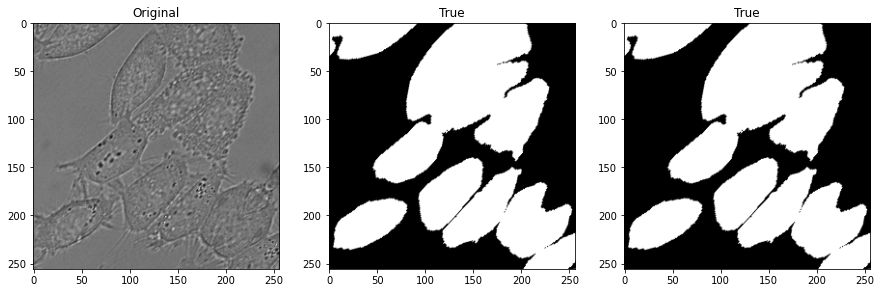

In [ ]:
ids = np.random.randint(0, X.shape[0], size = 1)
for index in ids:
    xx, yy , ww = X[index], Y[index], Y[index]
    visualize_pred(xx, yy, ww, title1="Original", title2="True", title3="True")

In [ ]:
# LOSS functions
def iou(true, pred):
    intersection = true * pred
    notTrue = 1 - true
    union = true + (notTrue * pred)
    return (K.sum(intersection, axis=-1) + K.epsilon()) / (K.sum(union, axis=-1) + K.epsilon())

def dice_coef(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true,y_pred):
    return 1-dice_coef(y_true,y_pred)

def bce_dice_loss(y_true, y_pred):
    return K.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

def jaccard_distance_loss(y_true, y_pred, smooth=100):
    intersection = K.sum(K.abs(y_true * y_pred), axis=-1)
    sum_ = K.sum(K.abs(y_true) + K.abs(y_pred), axis=-1)
    jac = (intersection + smooth) / (sum_ - intersection + smooth)
    return (1 - jac) * smooth

def iou_loss(y_true, y_pred):
    return 1 - iou(y_true, y_pred)

# for weighted_uNet only
def identity_loss(y_true, y_pred):
    return y_pred

def weighted_dice_and_binary_loss(y_pred, y_true):
    # y_pred, y_true, weights = X
    dice_loss = -K.log(dice_coef(y_true, y_pred))
    binary_loss = K.binary_crossentropy(y_true, y_pred)
    return binary_loss + dice_loss*2





# ** Train Test Split **###

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.03)
# X_val, X_test, Y_val, Y_test, W_val, W_test = train_test_split(X_val, Y_val, W_val, test_size=0.2)
print('Train: X = {} Y = {}'.format(X_train.shape, Y_train.shape))
# print('Val: X = {} Y = {}'.format(X_val.shape, Y_val.shape))
print('Test: X = {} Y = {}'.format(X_test.shape, Y_test.shape))

Train: X = (1482, 256, 256, 1) Y = (1482, 256, 256, 1)
Test: X = (46, 256, 256, 1) Y = (46, 256, 256, 1)


# **Building Blocks of Proposed Network**

In [ ]:
# Metrics

concat_axis = 3

def weighted_binary_loss(y_true, y_pred):
    # y_true, y_pred = X
    loss = K.binary_crossentropy(y_true, y_pred)
    return loss
def iou_batch(y_trues_in, y_preds_in):
    y_true = (y_trues_in >= 0.5).squeeze()
    y_pred = (y_preds_in >= 0.5).squeeze()
    unions = np.sum(y_pred | y_true, (1, 2))
    intersections = np.sum(y_pred * y_true, (1, 2))
    ious = np.maximum(0.0, np.ceil(20 * intersections / np.where(unions == 0.0, 1, unions) - 10) / 10)
    return np.mean(np.where(unions == 0, 1, ious))

def pixel_error(y_trues_in, y_preds_in):
    y_true = (y_trues_in >= 0.5).squeeze()
    y_pred = (y_preds_in >= 0.5).squeeze()
    eq = (y_true == y_pred).sum()
    ones = np.ones_like(y_true)
    return 1 - eq / ones.sum()

def dice_batch(y_trues_in, y_preds_in):
    y_true = (y_trues_in >= 0.5).squeeze()
    y_pred = (y_preds_in >= 0.5).squeeze()
    score = 0.0
    for im1, im2 in zip(y_true, y_pred):
        im_sum = im1.sum() + im2.sum()
        if im_sum == 0:
            score += 1.0
            continue
        intersection = np.logical_and(im1, im2)
        score += (2. * intersection.sum() / im_sum)
    return score / y_pred.shape[0]

def rand_error(y_trues_in, y_preds_in):
    y_true = (y_trues_in >= 0.5).squeeze()
    y_pred = (y_preds_in >= 0.5).squeeze()
    rand_index = 0
    for v1, v2 in zip(y_true, y_pred):
        n = v1.shape[0] * v1.shape[1]
        s1 = [n - v1.sum(), v1.sum()]
        s2 = [n - v2.sum(), v2.sum()]
        M = [[0,0], [0,0]]
        M[0][0] = np.logical_and(np.logical_not(v1), np.logical_not(v2)).sum()
        M[0][1] = np.logical_and(np.logical_not(v1), v2).sum()
        M[1][0] = np.logical_and(v1, np.logical_not(v2)).sum()
        M[1][1] = np.logical_and(v1, v2).sum()
        a, b = 0, 0
        for i in range(2):
            for j in range(2):
                c = M[i][j]
                a += (c * (c - 1))
                b += (c * (n - s1[i] - s2[j] + c))
        cur = (a + b) / (n * (n - 1))
        rand_index += cur
    rand_index /= y_true.shape[0]
    return 1 - rand_index



In [ ]:

# def conv2d_bn(x,filters,num_row,num_col,padding='same',strides=(1, 1), batch_norm=True ):

#     x = Conv2D(filters, (num_row, num_col),strides=strides,padding=padding,
#                                kernel_initializer='he_normal')(x)
#     if batch_norm != False:
#         x = BatchNormalization(axis=3, scale=False)(x)
#     x = Activation('relu')(x)
#     return x

In [ ]:
# #attention block
# def att_blck(x,g,inter_shape):
#   shape_x= K.int_shape(x)
#   shape_g= K.int_shape(g)

#   theta_x = Conv2D(inter_shape,(1,1),strides=(2,2),padding='same')(x)
#   shape_theta = K.int_shape(theta_x)

#   phi_g = Conv2D(inter_shape,(1,1),padding='same')(g)

#   concat_xg = Add()([phi_g,theta_x])
#   act_xg = Activation('relu')(concat_xg)
#   psi = Conv2D(1,(1,1),padding='same')(act_xg)
#   sigmoid_xg = Activation('sigmoid')(psi)
#   shape_sigmoid = K.int_shape(sigmoid_xg)

#   upsample_psi = UpSampling2D(size=(shape_x[1]//shape_sigmoid[1],shape_x[2]//shape_sigmoid[2]))(sigmoid_xg)
#   y = Multiply()([upsample_psi,x])
#   res = Conv2D(shape_x[3],(1,1),padding='same')(y)
#   res_bn = BatchNormalization()(res)
#   return res_bn

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Cropping2D, Conv2D, Conv2DTranspose, MaxPooling2D, Softmax, AveragePooling2D, Dropout
from tensorflow.keras.layers import Input, Add, Multiply, Lambda, Concatenate, Dropout,BatchNormalization,Activation
import tensorflow.keras.backend as K

def conv2d_bn(x,filters,num_row,num_col,padding='same',strides=(1, 1)):


    x = Conv2D(filters, (num_row, num_col),strides=strides,padding=padding,
                               kernel_initializer='he_normal')(x)
    x = BatchNormalization(axis=3, scale=False)(x)
    x = Activation('relu')(x)
    return x

In [ ]:
def inc_block_a(x):
    branch1x1 = conv2d_bn(x, 32, 1, 1)  # 32 filters of 1*1

    branch5x5 = conv2d_bn(x, 32, 1, 1)  #24 filters of 1*1
    branch5x5 = conv2d_bn(branch5x5, 32, 5, 5)

    branch3x3dbl = conv2d_bn(x, 48, 1, 1)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 48, 3, 3)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 48, 3, 3)

    branch_pool = AveragePooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch_pool = conv2d_bn(branch_pool, 32, 1, 1)
    # 32 + 24 + 32+ input_channels = 120
    x = Concatenate(axis=concat_axis)([branch1x1, branch5x5, branch3x3dbl, branch_pool])
    return x


In [ ]:
def reduction_block_a(x):
    branch3x3 = conv2d_bn(x, 96, 3, 3, strides=(2, 2), padding='same')

    branch3x3dbl = conv2d_bn(x, 48, 1, 1)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 64, 3, 3, padding='same')
    branch3x3dbl = conv2d_bn(branch3x3dbl, 64, 3, 3, strides=(2, 2), padding='same')

    branch_pool = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = Concatenate(axis=concat_axis)([branch3x3, branch3x3dbl, branch_pool])
    # 96 + 64 + input_channels
    return x

In [ ]:
# mixed 8: 8 x 8 x 1280
def reduction_block_b(x):
    branch3x3 = conv2d_bn(x, 96, 1, 1)
    branch3x3 = conv2d_bn(branch3x3, 128, 3, 3,strides=(2, 2), padding='same')

    branch7x7x3 = conv2d_bn(x, 64, 1, 1)
    branch7x7x3 = conv2d_bn(branch7x7x3, 64, 1, 7)
    branch7x7x3 = conv2d_bn(branch7x7x3, 64, 7, 1)
    branch7x7x3 = conv2d_bn( branch7x7x3, 64, 3, 3, strides=(2, 2), padding='same')

    branch_pool = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    #128 + 64 + in_channels
    x = Concatenate(axis=concat_axis)([branch3x3, branch7x7x3, branch_pool])
    return x

In [ ]:
def inc_block_b(x):
    branch1x1 = conv2d_bn(x, 128, 1, 1)

    branch7x7 = conv2d_bn(x, 96, 1, 1)
    branch7x7 = conv2d_bn(branch7x7, 96, 1, 7)
    branch7x7 = conv2d_bn(branch7x7, 96, 7, 1)

    branch7x7dbl = conv2d_bn(x, 96, 1, 1)
    branch7x7dbl = conv2d_bn(branch7x7dbl, 96, 7, 1)
    branch7x7dbl = conv2d_bn(branch7x7dbl, 96, 1, 7)
    branch7x7dbl = conv2d_bn(branch7x7dbl, 96, 7, 1)
    branch7x7dbl = conv2d_bn(branch7x7dbl, 96, 1, 7)

    branch_pool = AveragePooling2D((3, 3), strides=(1, 1),padding='same')(x)
    branch_pool = conv2d_bn(branch_pool, 128, 1, 1)
    # 92 + 64 + 64 +64

    x = Concatenate(axis=concat_axis)([branch1x1, branch7x7, branch7x7dbl, branch_pool])
    return x

In [ ]:
def inc_block_c(x):
    branch1x1 = conv2d_bn(x, 64, 1, 1)

    branch3x3 = conv2d_bn(x, 96, 1, 1)
    branch3x3_1 = conv2d_bn(branch3x3, 96, 1, 3)
    branch3x3_2 = conv2d_bn(branch3x3, 96, 3, 1)
    branch3x3 = Concatenate(axis=concat_axis)([branch3x3_1, branch3x3_2])

    branch3x3dbl = conv2d_bn(x, 96, 1, 1)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 96, 3, 3)
    branch3x3dbl_1 = conv2d_bn(branch3x3dbl, 96, 1, 3)
    branch3x3dbl_2 = conv2d_bn(branch3x3dbl, 96, 3, 1)
    branch3x3dbl = Concatenate(axis=concat_axis)([branch3x3dbl_1, branch3x3dbl_2])

    branch_pool = AveragePooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch_pool = conv2d_bn(branch_pool, 64, 1, 1)
    #64 + 96 + 96 + 96 + 64
    x = Concatenate(axis=concat_axis)( [branch1x1, branch3x3, branch3x3dbl, branch_pool])
    return x

In [ ]:
concat_axis = 3

def weighted_binary_loss(y_true, y_pred):
    # y_true, y_pred = X
    loss = K.binary_crossentropy(y_true, y_pred)
    return loss

def IncV3UNet():

    # with strategy.scope():
    inputs = Input((256,256,1), name='image_input')
    weight_inputs = Input((256, 256, 1))
    true_inputs = Input((256, 256, 1))

    # Contraction path
    c1 = conv2d_bn(inputs, 64, 3, 3, padding='same') # 256, 256, 32
    c1 = conv2d_bn(c1, 64, 3, 3, padding='same') # 256, 256,32
    p1 = MaxPooling2D((2,2))(c1) # 128, 128, 32
    c2 = inc_block_a(p1) # 128, 128, 120
    c2 = inc_block_a(c2) # 128, 128, 120
    p2 = reduction_block_a(c2) # 64, 64, 280
    c3 = inc_block_b(p2) # 64, 64, 256
    c3 = inc_block_b(c3) # 64, 64, 256
    p3 = reduction_block_b(c3) # 32, 32, 448
    c4 = inc_block_c(p3) # 32, 32, 512
    c4 = inc_block_c(c4) # 32, 32, 512
    c4 = Dropout(0.2)(c4)

    # Expansive path
    u5 = Conv2DTranspose(416, (2,2), strides = (2,2), padding = "same")(c4)
    u5 = Concatenate(axis=concat_axis)([u5, c3]) # 256 + 256
    c5 = inc_block_b(u5)
    c5 = inc_block_b(c5)

    u6 = Conv2DTranspose(256, (2,2), strides = (2,2), padding = "same")(c5)
    u6 =  Concatenate(axis=concat_axis)([u6, c2]) #(128+120)
    c6 = inc_block_a(u6)
    c6 = inc_block_a(c6)

    u7 = Conv2DTranspose(128, (2,2), strides = (2,2), padding = "same")(c6)
    u7 = Concatenate(axis=concat_axis)([u7, c1]) # (64+32)
    c7 = conv2d_bn(u7, 64, 3, 3, padding='same')
    c7 = conv2d_bn(c7, 64, 3, 3, padding='same')
    outputs = Conv2D(1, (1,1), activation='sigmoid', kernel_initializer='glorot_normal', name='seg_output')(c7)
    # loss1 = Lambda(weighted_binary_loss, trainable = False)([true_inputs, outputs])
    # loss1 = Multiply()([loss1, weight_inputs])
    model = Model(inputs=[inputs], outputs=[outputs])

    # mask_model = Model(inputs=[inputs, weight_inputs], outputs=[outputs])

    # mask_model = Model(inputs=[inputs, weight_inputs,true_inputs], outputs=[outputs])
    return model

In [ ]:
K.clear_session()
IncV3UNet_model = IncV3UNet()
IncV3UNet_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 64  640         ['image_input[0][0]']            
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 256, 256, 64  192        ['conv2d[0][0]']                 
 alization)                     )                                                             

In [ ]:
!pip install tensorflow-addons

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 1.1 MB 4.7 MB/s 


In [ ]:
import tensorflow_addons as tfa

IncV3UNet_model_file = 'IncV3UNet_model.h5'


reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.0000001,verbose=1)

# logdir = "logs/scalars/" + datetime.now().strftime("%Y%m%d-%H%M%S")
# tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir)
IncV3UNet_start =  datetime.now()

checkpointer = ModelCheckpoint(filepath= IncV3UNet_model_file, monitor='val_loss', mode='min', save_best_only=True)
IncV3UNet_model.compile(optimizer = Adam(learning_rate=0.0005), loss =tfa.losses.SigmoidFocalCrossEntropy(), metrics=['accuracy', dice_coef])

losses = list()
val_losses = list()

# if os.path.isfile(model_name):
#     print('Loaded saved Model!')
#     AssyUnet_model.load_weights(model_name)

In [ ]:
from sklearn.utils import validation
IncV3Unet_model_hist = IncV3UNet_model.fit(
    X_train, Y_train,
    batch_size = 16 ,
    epochs = 60,
    validation_split = 0.1,
    callbacks = [checkpointer,reduce_lr],
    shuffle = True,
    verbose = 1
)

IncV3Unet_end =  datetime.now()

IncV3Unet_traintime = IncV3Unet_end - IncV3UNet_start
# losses += list(history.history['loss'])
# val_losses += list(history.history['val_loss'])

Epoch 1/60
84/84 [==============================] - 50s 317ms/step - loss: 0.0322 - accuracy: 0.8294 - dice_coef: 0.7107 - val_loss: 0.1029 - val_accuracy: 0.4266 - val_dice_coef: 0.3716 - lr: 5.0000e-04
Epoch 2/60
84/84 [==============================] - 22s 264ms/step - loss: 0.0199 - accuracy: 0.8882 - dice_coef: 0.7923 - val_loss: 0.6700 - val_accuracy: 0.4266 - val_dice_coef: 0.0299 - lr: 5.0000e-04
Epoch 3/60
84/84 [==============================] - 22s 264ms/step - loss: 0.0173 - accuracy: 0.8991 - dice_coef: 0.8161 - val_loss: 0.7112 - val_accuracy: 0.4266 - val_dice_coef: 0.0366 - lr: 5.0000e-04
Epoch 4/60
84/84 [==============================] - 22s 264ms/step - loss: 0.0154 - accuracy: 0.9064 - dice_coef: 0.8360 - val_loss: 0.2440 - val_accuracy: 0.4284 - val_dice_coef: 0.2506 - lr: 5.0000e-04
Epoch 5/60
84/84 [==============================] - 22s 263ms/step - loss: 0.0141 - accuracy: 0.9113 - dice_coef: 0.8493 - val_loss: 0.1475 - val_accuracy: 0.4399 - val_dice_coef: 0.36

In [ ]:
IncV3UNet_model_file = '/content/drive/MyDrive/CellTrackingDataset/PhCResult/DIC_IncV3Unet_FocalCE_model.h5'

IncV3UNet_model.save_weights(IncV3UNet_model_file)

In [ ]:
print(IncV3UNet_start)
print(IncV3Unet_end)
print(IncV3Unet_traintime)

2022-11-19 13:38:10.217331
2022-11-19 14:00:47.421588
0:22:37.204257


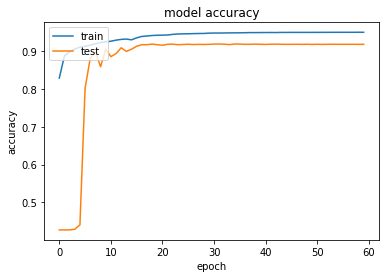

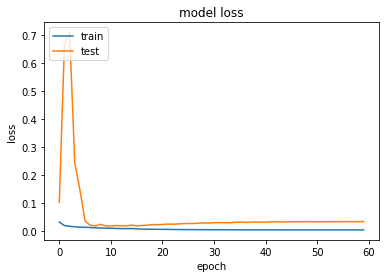

In [ ]:
# summarize history for accuracy
plt.plot(IncV3Unet_model_hist.history['accuracy'], )
plt.plot(IncV3Unet_model_hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(IncV3Unet_model_hist.history['loss'])
plt.plot(IncV3Unet_model_hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
IncV3Unet_model_hist.history.keys()

np.save('/content/drive/MyDrive/CellTrackingDataset/PhCResult/DIC_IncV3Unet_FocalCE_hist.npy', IncV3Unet_model_hist.history)

IncV3Unet_model_file = '/content/drive/MyDrive/CellTrackingDataset/PhCResult/DIC_IncV3Unet_FocalCE_model.hdf5'
IncV3UNet_model.save(IncV3Unet_model_file)

In [ ]:
# predictor = K.function([IncV3Unet_model.get_layer('image_input').input], [IncV3Unet_model.get_layer('seg_output').output])
Y_pred = IncV3UNet_model.predict(X_test)
# Y_pred = predictor(X_test)[0]
print('Pred : {}'.format(Y_pred.shape))
print('True : {}'.format(Y_test.shape))
print('Original : {}'.format(X_test.shape))

2/2 [==============================] - 4s 879ms/step
Pred : (46, 256, 256, 1)
True : (46, 256, 256, 1)
Original : (46, 256, 256, 1)


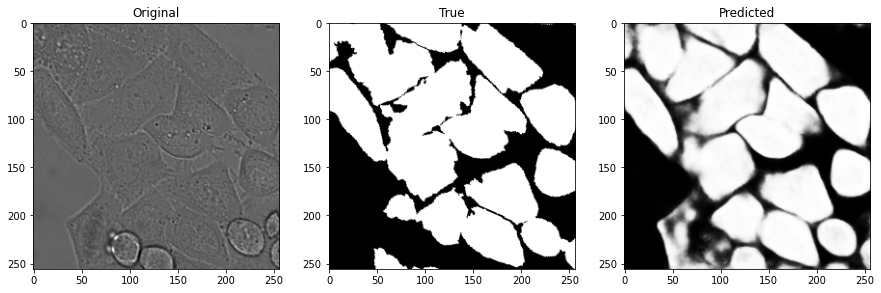

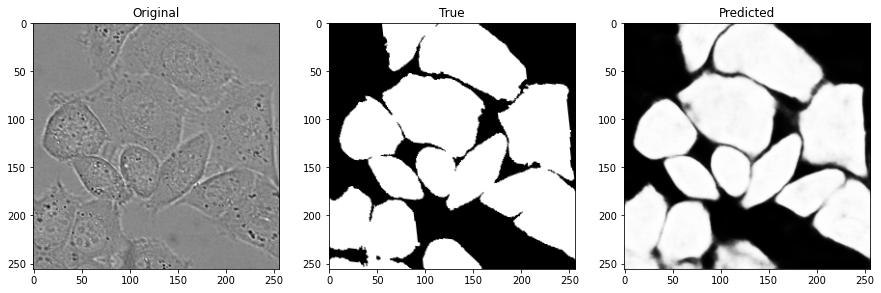

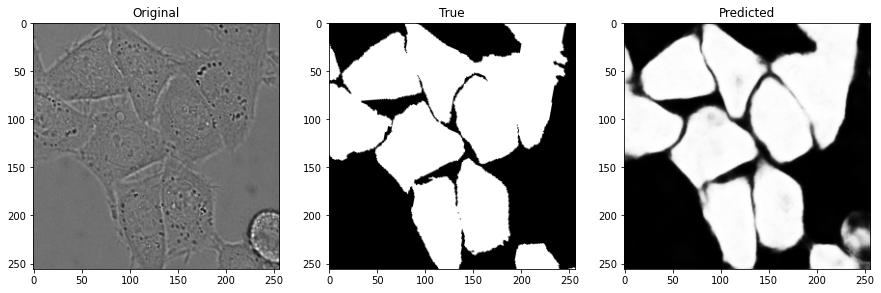

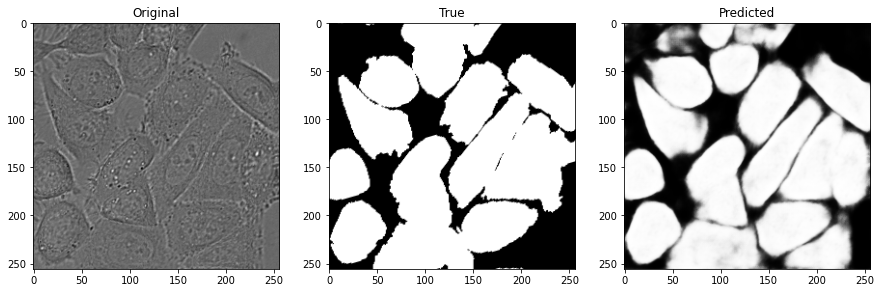

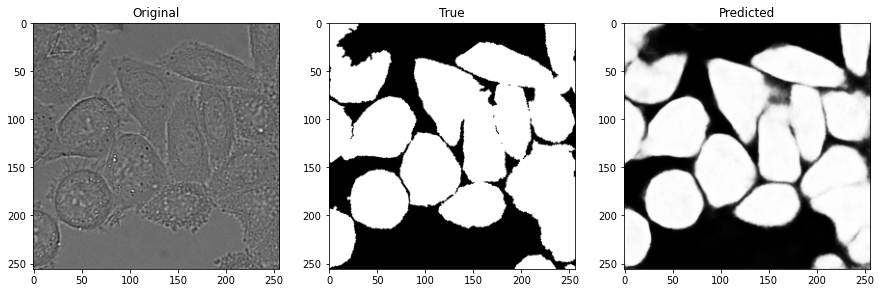

In [ ]:
# visualize results
total = X_test.shape[0]
ids = np.random.randint(0, total, size = 5)
for i in ids:
    visualize_pred(X_test[i], Y_test[i], Y_pred[i])

In [ ]:
iou_score = iou_batch(Y_test, Y_pred)
dice_score = dice_batch(Y_test, Y_pred)
pixel_err = pixel_error(Y_test, Y_pred)
rand_err = rand_error(Y_test, Y_pred)

print("Inception V3 U-Net Metrics ")
print('IOU   score : %.4f' % iou_score)
print('DICE  score : %.4f' % dice_score)
print('Pixel error : %.4f' % pixel_err)
print('Rand  error : %.4f' % rand_err)

# DIC Hela loss = Weight Cross Entropy Dataset Results for Inception UNet

# Inception V3 U-Net Metrics
# IOU   score : 0.8783
# DICE  score : 0.9559
# Pixel error : 0.0503
# Rand  error : 0.0947


Inception V3 U-Net Metrics 
IOU   score : 0.8696
DICE  score : 0.9536
Pixel error : 0.0524
Rand  error : 0.0984


In [ ]:
!mkdir DicHela_IncV3_Image_Result
import imageio
for i in range(len(Y_test)):
    # print(i)
    imageio.imwrite('DicHela_IncV3_Image_Result/Y_test_DIC_FocalLoss_Iv3_pred' + str(i) + '.tiff', Y_pred[i,:,:,0])
    # imageio.imwrite('FluoMSC_IncV3_Image_Result/Y_test_FM_Iv3_pred' + str(i) + '.tiff', Y_pred[i,:,:,0])
    imageio.imwrite('DicHela_IncV3_Image_Result/Y_test_DIC_FocalLoss_Iv3_true' + str(i) + '.tiff', Y_test[i,:,:,0])
    # imageio.imwrite('FluoMSC_IncV3_Image_Result/Y_test_FM_input' + str(i) + '.tiff', X_test[0])

In [ ]:
!zip -r /content/DicHela_IncV3_Image_Result.zip '/content/DicHela_IncV3_Image_Result'

  adding: content/DicHela_IncV3_Image_Result/ (stored 0%)
  adding: content/DicHela_IncV3_Image_Result/Y_test_DIC_FocalLoss_Iv3_pred19.tiff (deflated 11%)
  adding: content/DicHela_IncV3_Image_Result/Y_test_DIC_FocalLoss_Iv3_true34.tiff (deflated 94%)
  adding: content/DicHela_IncV3_Image_Result/Y_test_DIC_FocalLoss_Iv3_true38.tiff (deflated 92%)
  adding: content/DicHela_IncV3_Image_Result/Y_test_DIC_FocalLoss_Iv3_true23.tiff (deflated 94%)
  adding: content/DicHela_IncV3_Image_Result/Y_test_DIC_FocalLoss_Iv3_pred3.tiff (deflated 11%)
  adding: content/DicHela_IncV3_Image_Result/Y_test_DIC_FocalLoss_Iv3_true26.tiff (deflated 93%)
  adding: content/DicHela_IncV3_Image_Result/Y_test_DIC_FocalLoss_Iv3_pred29.tiff (deflated 12%)
  adding: content/DicHela_IncV3_Image_Result/Y_test_DIC_FocalLoss_Iv3_true19.tiff (deflated 94%)
  adding: content/DicHela_IncV3_Image_Result/Y_test_DIC_FocalLoss_Iv3_true32.tiff (deflated 93%)
  adding: content/DicHela_IncV3_Image_Result/Y_test_DIC_FocalLoss_Iv3_

# **Inception U-Net Model Training**

In [ ]:
def weighted_binary_loss(y_true, y_pred):
    # y_true, y_pred = X
    loss = K.binary_crossentropy(y_true, y_pred)
    return loss

def block(prevlayer, a, b, pooling):
    conva = Conv2D(a, (3, 3), activation='relu', padding='same')(prevlayer)
    conva = BatchNormalization()(conva)
    conva = Conv2D(b, (3, 3), activation='relu', padding='same')(conva)
    conva = BatchNormalization()(conva)
    if True == pooling:
        conva = MaxPooling2D(pool_size=(2, 2))(conva)


    convb = Conv2D(a, (5, 5), activation='relu', padding='same')(prevlayer)
    convb = BatchNormalization()(convb)
    convb = Conv2D(b, (5, 5), activation='relu', padding='same')(convb)
    convb = BatchNormalization()(convb)
    if True == pooling:
        convb = MaxPooling2D(pool_size=(2, 2))(convb)

    convc = Conv2D(b, (1, 1), activation='relu', padding='same')(prevlayer)
    convc = BatchNormalization()(convc)
    if True == pooling:
        convc = MaxPooling2D(pool_size=(2, 2))(convc)

    convd = Conv2D(a, (3, 3), activation='relu', padding='same')(prevlayer)
    convd = BatchNormalization()(convd)
    convd = Conv2D(b, (1, 1), activation='relu', padding='same')(convd)
    convd = BatchNormalization()(convd)
    if True == pooling:
        convd = MaxPooling2D(pool_size=(2, 2))(convd)

    up = Concatenate(axis = 3)([conva, convb, convc, convd])
    return up


def Inc_unet():
    inputs = Input((256, 256, 1), name='image_input')

    conv1 = block(inputs, 16, 32, True)

    conv2 = block(conv1, 32, 64, True)

    conv3 = block(conv2, 64, 128, True)

    conv4 = block(conv3, 128, 256, True)

    conv5 = block(conv4, 256, 512, True)

    # **** decoding ****
    xx = Concatenate(axis = 3)([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv5), conv4])
    up1 = block(xx, 512, 128, False)

    xx = Concatenate(axis = 3)([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(up1), conv3])
    up2 = block(xx, 256, 64, False)

    xx = Concatenate(axis = 3)([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(up2), conv2])
    up3 = block(xx, 128, 32, False)


    xx = Concatenate(axis = 3)([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(up3), conv1])
    up4 = block(xx, 64, 16, False)

    xx = Concatenate(axis = 3)([Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(up4), inputs])

    xx = Conv2D(32, (3, 3), activation='relu', padding='same')(xx)
    xx = Conv2D(1, (1, 1), activation='sigmoid', padding='same', name='seg_output')(xx)
    model = Model(inputs=[inputs], outputs=[xx])

    return model

In [ ]:
IncUnet_model = Inc_unet()
IncUnet_model.summary()

In [ ]:

IncUnet_model_name = 'IncUnet_model.h5'


reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.0000001,verbose=1)

# logdir = "logs/scalars/" + datetime.now().strftime("%Y%m%d-%H%M%S")
# tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir)


checkpointer = ModelCheckpoint(filepath=IncUnet_model_name, monitor='val_loss', mode='min', save_best_only=True)
IncUnet_model.compile(optimizer = Adam(learning_rate=0.0005), loss = weighted_binary_loss, metrics=['accuracy', dice_coef])

IncUnet_start = datetime.now()

losses = list()
val_losses = list()

# if os.path.isfile(model_name):
#     print('Loaded saved Model!')
#     IncUnet_model.load_weights(model_name)

In [ ]:

IncUnet_model_hist = IncUnet_model.fit(
    X_train, Y_train,
    batch_size = 16 ,
    epochs = 60,
    validation_split = 0.1,
    callbacks = [checkpointer,reduce_lr],
    shuffle = True,
    verbose = 1
)

IncUnet_end =  datetime.now()

IncUnet_traintime = IncUnet_end - IncUnet_start


In [ ]:
IncUnet_model_file = '/content/drive/MyDrive/CellTrackingDataset/PhCResult/FluoMSC_IncUnet_model_1.hdf5'
IncUnet_model.save(IncUnet_model_file)

In [ ]:
IncUnet_model_hist.history.keys()

np.save('/content/drive/MyDrive/CellTrackingDataset/PhCResult/FluoMSC_IncUnet_model_hist_1.npy', IncUnet_model_hist.history)


In [ ]:
# summarize history for accuracy
plt.plot(IncUnet_model_hist.history['accuracy'], )
plt.plot(IncUnet_model_hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(IncUnet_model_hist.history['loss'])
plt.plot(IncUnet_model_hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
# IncUnet_predictor = K.function([IncUnet_model.get_layer('image_input').input], [IncUnet_model.get_layer('seg_output').output])
Y_pred = IncUnet_model.predict(X_test)
# Y_pred = IncUnet_predictor(X_test)[0]
print('Pred : {}'.format(Y_pred.shape))
print('True : {}'.format(Y_test.shape))
print('Original : {}'.format(X_test.shape))

In [ ]:
total = X_test.shape[0]
ids = np.random.randint(0, total, size = 5)
for i in ids:
    visualize_pred(X_test[i], Y_test[i], Y_pred[i])

In [ ]:
iou_score = iou_batch(Y_test, Y_pred)
dice_score = dice_batch(Y_test, Y_pred)
pixel_err = pixel_error(Y_test, Y_pred)
rand_err = rand_error(Y_test, Y_pred)
print('IOU   score : %.4f' % iou_score)
print('DICE  score : %.4f' % dice_score)
print('Pixel error : %.4f' % pixel_err)
print('Rand  error : %.4f' % rand_err)

# Fluo MSC Hela inception Unet V1

# IOU   score : 0.7021
# DICE  score : 0.9040
# Pixel error : 0.0109
# Rand  error : 0.0215

In [ ]:
!mkdir FluoMSC_IncV1_Image_Result
import imageio
for i in range(len(Y_test)):
    # print(i)
    imageio.imwrite('FluoMSC_IncV1_Image_Result/FluoMSC_Iv1_pred' + str(i) + '.tiff', Y_pred[i,:,:,0])
    imageio.imwrite('FluoMSC_IncV1_Image_Result/FluoMSC_DIC_Iv1_true' + str(i) + '.tiff', Y_test[i,:,:,0])
    imageio.imwrite('FluoMSC_IncV1_Image_Result/FluoMSC_DIC_input' + str(i) + '.tiff', X_test[i])

!zip -r /content/DIC_INCV1_Result.zip '/content/FluoMSC_IncV1_Image_Result'

# **Classical U-Net**


In [ ]:
def unet():
    inputs = Input((256, 256, 1), name='image_input')
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv5)

    up6 = Concatenate(axis=3)([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv5), conv4])
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(up6)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv6)

    up7 = Concatenate(axis=3)([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv6), conv3])
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(up7)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv7)

    up8 = Concatenate(axis=3)([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv7), conv2])
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(up8)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv8)

    up9 = Concatenate(axis=3)([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv8), conv1])
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(up9)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv9)

    conv10 = Conv2D(1, (1, 1), activation='sigmoid', name='seg_output')(conv9)


    model = Model(inputs=[inputs], outputs=[conv10])

    return model

In [ ]:
unet_model = unet()
unet_model.summary()

In [ ]:
unet_model_name = 'unet_model.h5'

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.0000001,verbose=1)

checkpointer = ModelCheckpoint(filepath=unet_model_name, monitor='val_loss', mode='min', save_best_only=True)
unet_model.compile(optimizer = Adam(learning_rate=0.0001), loss = weighted_binary_loss, metrics=['accuracy', dice_coef])

losses = list()
val_losses = list()

Unet_start =  datetime.now()

# if os.path.isfile(model_name):
#     print('Loaded saved Model!')
#     unet_model.load_weights(model_name)

In [ ]:
from sklearn.utils import validation
unet_model_history = unet_model.fit(
    X_train, Y_train,
    batch_size = 16,
    epochs = 60,
    validation_split = 0.1,
    callbacks = [checkpointer,reduce_lr],
    shuffle = True,
    verbose = 1
)

Unet_end =  datetime.now()

Unet_traintime = Unet_end - Unet_start

In [ ]:
unet_model_file = '/content/drive/MyDrive/CellTrackingDataset/PhCResult/FluiMSC_unet_model.hdf5'
unet_model.save(unet_model_file)

np.save('/content/drive/MyDrive/CellTrackingDataset/PhCResult/FluoMSC_Unet_model_hist.npy', unet_model_history.history)


In [ ]:
unet_predictor = K.function([unet_model.get_layer('image_input').input], [unet_model.get_layer('seg_output').output])
Y_pred = unet_predictor(X_test)[0]
print('Pred : {}'.format(Y_pred.shape))
print('True : {}'.format(Y_test.shape))
print('Original : {}'.format(X_test.shape))


In [ ]:
iou_score = iou_batch(Y_test, Y_pred)
dice_score = dice_batch(Y_test, Y_pred)
pixel_err = pixel_error(Y_test, Y_pred)
rand_err = rand_error(Y_test, Y_pred)
print('IOU   score : %.4f' % iou_score)
print('DICE  score : %.4f' % dice_score)
print('Pixel error : %.4f' % pixel_err)
print('Rand  error : %.4f' % rand_err)



# IOU   score : 0.6521
# DICE  score : 0.8855
# Pixel error : 0.0128
# Rand  error : 0.0251

In [ ]:
!mkdir DIC_UNET_Result
import imageio
for i in range(len(Y_test)):
    # print(i)
    imageio.imwrite('DIC_UNET_Result/Y_test_DIC_UNET_pred' + str(i) + '.tiff', Y_pred[i,:,:,0])
    imageio.imwrite('DIC_UNET_Result/Y_test_DIC_UNET_true' + str(i) + '.tiff', Y_test[i,:,:,0])
    imageio.imwrite('DIC_UNET_Result/Y_test_DIC_input' + str(i) + '.tiff', X_test[0])

!zip -r /content/DIC_INCV1_Result.zip '/content/DIC_UNET_Result'

# **SQUEEZE UNET**

In [ ]:
from tensorflow.keras.layers import DepthwiseConv2D
def fire_module(x, fire_id, squeeze=16, expand=64):
    f_name = "fire{0}/{1}"
    channel_axis = -1 #if K.image_data_format() == 'channels_first' else -1

    x = Conv2D(squeeze, (1, 1), activation='relu', padding='same', name=f_name.format(fire_id, "squeeze1x1"))(x)
    x = BatchNormalization(axis=channel_axis)(x)

    left = Conv2D(expand, 1,  activation='relu', padding='same', name=f_name.format(fire_id, "expand1x1"))(x)
    right = DepthwiseConv2D((3,3),  activation='relu', padding='same', name=f_name.format(fire_id, "expand3x3"))(x)

    x = Concatenate(axis=channel_axis)([left, right])
    return x

In [ ]:
def SqueezeUNet(num_classes=None, deconv_ksize=3, dropout=0.3, activation='sigmoid'):
    """SqueezeUNet is a implementation based in SqueezeNetv1.1 and unet for semantic segmentation
    :param inputs: input layer.
    :param num_classes: number of classes.
    :param deconv_ksize: (width and height) or integer of the 2D deconvolution window.
    :param dropout: dropout rate
    :param activation: type of activation at the top layer.
    :returns: SqueezeUNet model
    """

    inputs = Input((256,256,1), name='image_input')

    channel_axis = -1 #if K.image_data_format() == 'channels_first' else -1
    if num_classes is None:
        num_classes = K.int_shape(inputs)[channel_axis]

    x01 = Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='relu', name='conv1')(inputs)
    x02 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), name='pool1', padding='same')(x01)
    print("x02 shape")
    print(x02.shape)
    x03 = fire_module(x02, fire_id=2, expand=64)
    x04 = fire_module(x03, fire_id=3, expand=64)
    x05 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), name='pool3', padding="same")(x04)

    x06 = fire_module(x05, fire_id=4, expand=128)
    x07 = fire_module(x06, fire_id=5, expand=128)
    x08 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), name='pool5', padding="same")(x07)

    x09 = fire_module(x08, fire_id=6, expand=192)
    x10 = fire_module(x09, fire_id=7, expand=192)
    x11 = fire_module(x10, fire_id=8, expand=256)
    x12 = fire_module(x11, fire_id=9, expand=256)

    if dropout != 0.0:
        x12 = Dropout(dropout)(x12)

    up1 = Concatenate(axis=channel_axis)([
        Conv2DTranspose(192, deconv_ksize, strides=(1, 1), padding='same')(x12),
        x10,])
    up1 = fire_module(up1, fire_id=10, expand=192)

    up2 = Concatenate(axis=channel_axis)([
        Conv2DTranspose(128, deconv_ksize, strides=(1, 1), padding='same')(up1),
        x08,])
    up2 = fire_module(up2, fire_id=11, expand=128)

    up3 = Concatenate(axis=channel_axis)([
        Conv2DTranspose(64, deconv_ksize, strides=(2, 2), padding='same')(up2),
        x05,])
    up3 = fire_module(up3, fire_id=12,  expand=64)

    up4 = Concatenate(axis=channel_axis)([
        Conv2DTranspose(32, deconv_ksize, strides=(2, 2), padding='same')(up3),
        x02,
    ])
    up4 = fire_module(up4, fire_id=13, expand=32)
    up4 = UpSampling2D(size=(2, 2))(up4)

    x = Concatenate(axis=channel_axis)([up4, x01])
    x = Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='relu')(x)
    # x = UpSampling2D(size=(2, 2))(x)
    x = Conv2D(num_classes, (1, 1), activation=activation)(x)

    return Model(inputs=inputs, outputs=x)

In [ ]:
K.clear_session()
SUnet_model = SqueezeUNet()
SUnet_model.summary()

In [ ]:

def weighted_binary_loss(y_true, y_pred):
    # y_true, y_pred = X
    loss = K.binary_crossentropy(y_true, y_pred)
    return loss

model_name = 'SUnet_model_dep.h5'


reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=6, min_lr=0.0000001,verbose=1)

# logdir = "logs/scalars/" + datetime.now().strftime("%Y%m%d-%H%M%S")
# tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir)
SUnet_start =  datetime.now()

checkpointer = ModelCheckpoint(filepath=model_name, monitor='val_loss', mode='min', save_best_only=True)
SUnet_model.compile(optimizer = Adam(learning_rate=0.00005), loss = weighted_binary_loss, metrics=['accuracy',dice_coef])

losses = list()
val_losses = list()



In [ ]:
from sklearn.utils import validation
Snet_model_hist = SUnet_model.fit(
    X_train, Y_train,
    batch_size = 16 ,
    epochs = 60,
    validation_split = 0.1,
    callbacks = [checkpointer,reduce_lr],
    shuffle = True,
    verbose = 1
)

SUnet_end =  datetime.now()

SUnet_traintime = SUnet_end - SUnet_start
losses += list(Snet_model_hist.history['loss'])
val_losses += list(Snet_model_hist.history['val_loss'])

In [ ]:
# summarize history for accuracy
plt.plot(Snet_model_hist.history['accuracy'], )
plt.plot(Snet_model_hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(Snet_model_hist.history['loss'])
plt.plot(Snet_model_hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
Snet_model_hist.history.keys()


# predictor = K.function([SUnet_model.get_layer('image_input').input], [SUnet_model.get_layer('seg_output').output])
y_pred = SUnet_model.predict(X_test)
# Y_pred = predictor(X_test)[0]
print('Pred : {}'.format(y_pred.shape))
print('True : {}'.format(Y_test.shape))
print('Original : {}'.format(X_test.shape))


In [ ]:
# unet_model_history.history.keys()


# np.save('unet_model_history.npy', unet_model_history.history)
np.save('/content/drive/MyDrive/CellTrackingDataset/PhCResult/FluoMSC_SUnet_model_hist.npy', Snet_model_hist.history)


In [ ]:
# Metrics
def iou_batch(y_trues_in, y_preds_in):
    y_true = (y_trues_in >= 0.5).squeeze()
    y_pred = (y_preds_in >= 0.5).squeeze()
    unions = np.sum(y_pred | y_true, (1, 2))
    intersections = np.sum(y_pred * y_true, (1, 2))
    ious = np.maximum(0.0, np.ceil(20 * intersections / np.where(unions == 0.0, 1, unions) - 10) / 10)
    return np.mean(np.where(unions == 0, 1, ious))

def pixel_error(y_trues_in, y_preds_in):
    y_true = (y_trues_in >= 0.5).squeeze()
    y_pred = (y_preds_in >= 0.5).squeeze()
    eq = (y_true == y_pred).sum()
    ones = np.ones_like(y_true)
    return 1 - eq / ones.sum()

def dice_batch(y_trues_in, y_preds_in):
    y_true = (y_trues_in >= 0.5).squeeze()
    y_pred = (y_preds_in >= 0.5).squeeze()
    score = 0.0
    for im1, im2 in zip(y_true, y_pred):
        im_sum = im1.sum() + im2.sum()
        if im_sum == 0:
            score += 1.0
            continue
        intersection = np.logical_and(im1, im2)
        score += (2. * intersection.sum() / im_sum)
    return score / y_pred.shape[0]

def rand_error(y_trues_in, y_preds_in):
    y_true = (y_trues_in >= 0.5).squeeze()
    y_pred = (y_preds_in >= 0.5).squeeze()
    rand_index = 0
    for v1, v2 in zip(y_true, y_pred):
        n = v1.shape[0] * v1.shape[1]
        s1 = [n - v1.sum(), v1.sum()]
        s2 = [n - v2.sum(), v2.sum()]
        M = [[0,0], [0,0]]
        M[0][0] = np.logical_and(np.logical_not(v1), np.logical_not(v2)).sum()
        M[0][1] = np.logical_and(np.logical_not(v1), v2).sum()
        M[1][0] = np.logical_and(v1, np.logical_not(v2)).sum()
        M[1][1] = np.logical_and(v1, v2).sum()
        a, b = 0, 0
        for i in range(2):
            for j in range(2):
                c = M[i][j]
                a += (c * (c - 1))
                b += (c * (n - s1[i] - s2[j] + c))
        cur = (a + b) / (n * (n - 1))
        rand_index += cur
    rand_index /= y_true.shape[0]
    return 1 - rand_index



In [ ]:
iou_score = iou_batch(Y_test, y_pred)
dice_score = dice_batch(Y_test, y_pred)
pixel_err = pixel_error(Y_test, y_pred)
rand_err = rand_error(Y_test, y_pred)
print('IOU   score : %.4f' % iou_score)
print('DICE  score : %.4f' % dice_score)
print('Pixel error : %.4f' % pixel_err)
print('Rand  error : %.4f' % rand_err)

#Squeeze Net
# IOU   score : 0.8319
# DICE  score : 0.9409
# Pixel error : 0.0081
# Rand  error : 0.0160

#50 epochs execution result
# IOU   score : 0.8106
# DICE  score : 0.9372
# Pixel error : 0.0084
# Rand  error : 0.0167

#100 epochs result
# IOU   score : 0.8213
# DICE  score : 0.9376
# Pixel error : 0.0082
# Rand  error : 0.0163





In [ ]:
SUNet_model_file = '/content/drive/MyDrive/CellTrackingDataset/PhCResult/FluoMSC_SUnet_model.h5'

SUnet_model.save_weights(SUNet_model_file)

In [ ]:
!mkdir DIC_SUNET_Result
import imageio
for i in range(len(Y_test)):
    # print(i)
    imageio.imwrite('DIC_SUNET_Result/Y_test_DIC_SUNET_pred' + str(i) + '.tiff', Y_pred[i,:,:,0])
    imageio.imwrite('DIC_SUNET_Result/Y_test_DIC_SUNET_true' + str(i) + '.tiff', Y_test[i,:,:,0])
    imageio.imwrite('DIC_SUNET_Result/Y_test_DIC_input' + str(i) + '.tiff', X_test[0])

!zip -r /content/DIC_SUNET_Result.zip '/content/DIC_SUNET_Result'